In [24]:
%load_ext autoreload
%autoreload 2

from folde.util import load_checkpointed_model_eval, convert_compaign_result_collection_to_df, DMS_SHORTNAMES
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

results = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    '250717-spg1-ablation',
    []
)
mutant_df, round_metrics_df = convert_compaign_result_collection_to_df(results)
round_metrics_df['dms_shortname'] = round_metrics_df.dms_id.apply(lambda x: DMS_SHORTNAMES[x])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Loading results for DMSs: {'SPG1_STRSG_Olson_2014'}


In [25]:
round_metrics_df.config_name.unique()

array(['FolDE-no-constantliar', 'RandomToRandomForest',
       'FolDE-long-training', 'FolDE-no-naturalnessTraining',
       'FolDE-with-Devariancing',
       'FolDE-less-naturalnessTraining-5epochs',
       'FolDE-shrink-and-perturb-06-01', 'FolDE-no-zeroShot',
       'FolDE-no-MLP', 'FolDE-shrink-and-perturb-02-01', 'Random',
       'FolDE-no-BTLoss', 'FolDE-no-ensemble',
       'FolDE-less-naturalnessTraining-20epochs', 'FolDE-base',
       'FolDE-no-naturalnessTraining-or-ensemble',
       'FolDE-less-naturalnessTraining-1epochs',
       'FolDE-no-naturalnessTraining-or-constantLiar'], dtype=object)

Text(0.5, 0, 'Round')

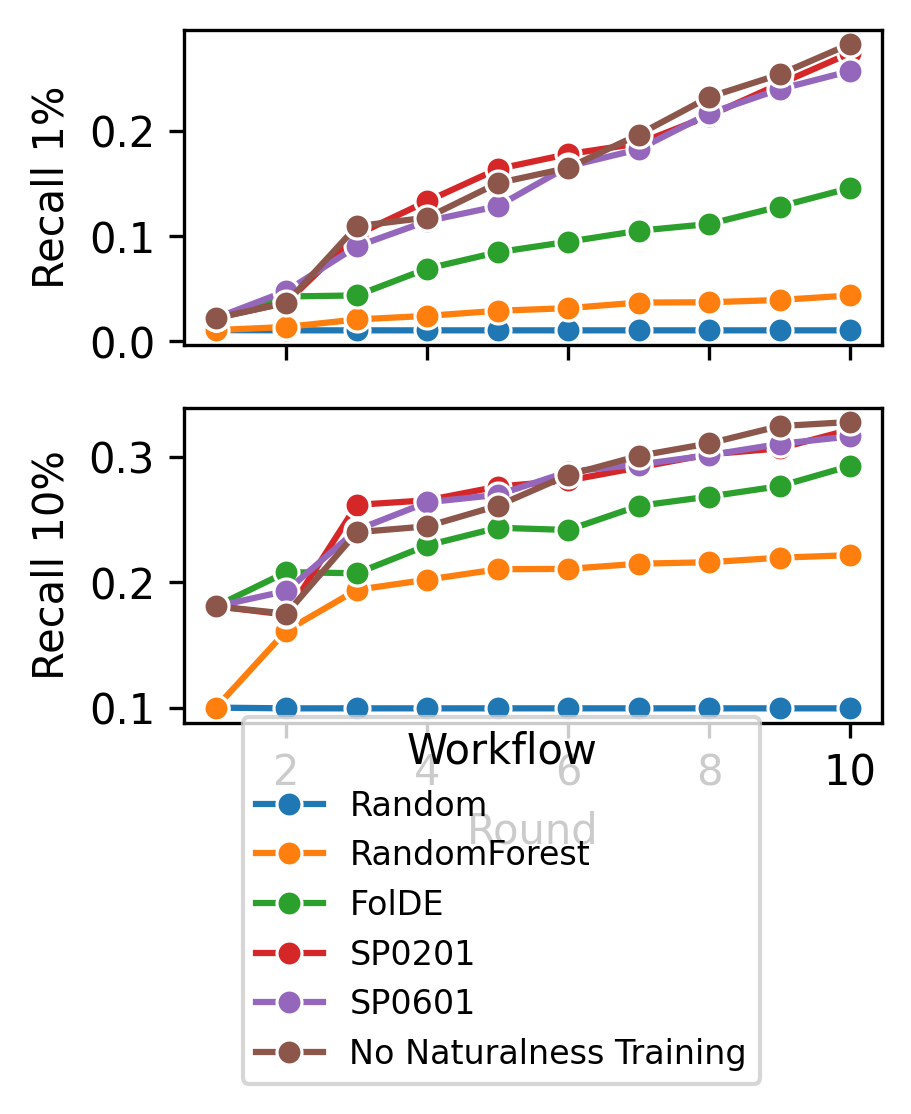

In [27]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3, 3), sharex=True, dpi=300)

# CONFIGS = [c for c in round_metrics_df.config_name.unique()]

CONFIGS = [
    ('Random', 'Random'),
    ('RandomToRandomForest', 'RandomForest'),
    ('FolDE-base', 'FolDE'),
    ('FolDE-shrink-and-perturb-02-01', 'SP0201'),
    ('FolDE-shrink-and-perturb-06-01', 'SP0601'),
    # ('FolDE-long-training', 'Extra long activity training (500 epochs)'),
    # ('FolDE-with-Devariancing', 'With Devariancing'),
    # ('FolDE-no-constantliar', 'No ConstantLiar'),
    ('FolDE-no-naturalnessTraining', 'No Naturalness Training'),
]
plot_df = round_metrics_df.copy()
plot_df['config_name'] = plot_df.config_name.apply(lambda x: dict(CONFIGS).get(x, x))

for ax, metric in zip([ax1, ax2], [ 'held_out_1pct_recall', 'held_out_10pct_recall']):
    sns.lineplot(
        ax=ax,
        data=plot_df[plot_df.config_name.isin([c[1] for c in CONFIGS])],
        # y='held_out_activity_spearman',
        y=metric,
        # y='held_out_1pct_auc',
        # y='held_out_activity_spearman',
        x='round_num',
        hue='config_name',
        errorbar=None,
        marker='o',
        hue_order=[c[1] for c in CONFIGS],
        # style='config_name',
        # errorbar=None
    )

# Disable ax1 legend
ax1.get_legend().remove()
ax2.legend(
    title='Workflow',
    loc='lower right',
    bbox_to_anchor=(0.85, -1.2),
    fontsize=8
)
ax1.set_ylabel('Recall 1%')
ax2.set_ylabel('Recall 10%')
ax2.set_xlabel('Round')
